In [2]:
# ENV_NAME = "MiniGrid-Empty-16x16-v0"
# OFFLINE_DATASET_VERSION = 5

ENV_NAME = "MiniGrid-LavaGapS5-v0"
OFFLINE_DATASET_VERSION = 0
ENV_SEED = 42

## Train expert policy w/ online RL

In [3]:
import os
import sys

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from gymnasium import spaces
from rl_zoo3.train import train
from stable_baselines3 import PPO
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import minari
from minari import DataCollector


torch.manual_seed(42)

/Users/a1111/micromamba/envs/corl-minari-nocuda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/a1111/micromamba/envs/corl-minari-nocuda/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [4]:
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class MinigridFeaturesExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.Space, features_dim: int = 512,
                 normalized_image: bool = False) -> None:
        super().__init__(observation_space, features_dim)
        n_input_channels = observation_space.shape[0]
        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 16, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(16, 32, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(32, 64, (2, 2)),
            nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            obs_tensor = torch.as_tensor(observation_space.sample()[None]).float()
            n_flatten = self.cnn(obs_tensor).shape[1]
        
        self.linear = nn.Sequential(nn.Linear(n_flatten, features_dim), nn.ReLU())
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(self.cnn(x))

In [5]:
# # TRAIN EXPERT POLICY

# import minigrid
# from minigrid.wrappers import ImgObsWrapper

# policy_kwargs = dict(
#     features_extractor_class=MinigridFeaturesExtractor,
#     features_extractor_kwargs=dict(features_dim=128)
# )

# env = gym.make(ENV_NAME)
# env = ImgObsWrapper(env)

# model = PPO("CnnPolicy", env, policy_kwargs=policy_kwargs, verbose=1)
# model.learn(2e5)

# # Save current model as best model
# model.save(f"./logs/ppo/{ENV_NAME}/best_model")

In [6]:
from gymnasium.utils import RecordConstructorArgs
from minigrid.wrappers import ImgObsWrapper as MGImgObsWrapper

class RecordedImgObsWrapper(MGImgObsWrapper, RecordConstructorArgs):
    def __init__(self, env):
        RecordConstructorArgs.__init__(self)
        super().__init__(env)

In [7]:
# # COLLECT OFFLINE DATASET 

# env = DataCollector(RecordedImgObsWrapper(gym.make(ENV_NAME)), data_format="parquet")
# path = os.path.abspath('') + f'/logs/ppo/{ENV_NAME}/best_model'
# agent = PPO.load(path)

# total_episodes = 1_000
# # total_episodes = 1

# for _ in tqdm(range(total_episodes)):
#     obs, _ = env.reset()
#     terminated = False
#     truncated = False
#     while not (terminated or truncated):
#         action, _ = agent.predict(obs, deterministic=True)
#         obs, rew, terminated, truncated, info = env.step(action)

In [8]:
# dataset_name = f"{ENV_NAME}/expert-v{OFFLINE_DATASET_VERSION}"
# dataset = env.create_dataset(
#     dataset_id=dataset_name,
#     algorithm_name="ExpertPolicy",
#     code_permalink="https://minari.farama.org/tutorials/behavioral_cloning",
#     author="Farama",
#     author_email="contact@farama.org",
# )

# print(f"Collected dataset:\n{dataset_name}")

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNetwork(nn.Module):
    def __init__(self, observation_space, output_dim):
        super().__init__()

        obs_shape = observation_space.shape
        input_channels = obs_shape[2] if len(obs_shape) == 3 else 1

        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 16, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(16, 32, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(32, 64, (2, 2)),
            nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            sample_obs = observation_space.sample()
            sample_obs = torch.from_numpy(sample_obs).permute(2, 0, 1).unsqueeze(0).float() if len(obs_shape) == 3 else torch.from_numpy(sample_obs).unsqueeze(0).unsqueeze(0).float()
            n_flatten = self.cnn(sample_obs).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, 512),
            nn.ReLU()
        )
        self.head = nn.Linear(512, output_dim)

    def forward(self, x):
        # Expect either (B,H,W,C) or (H,W,C)
        if x.dim() == 3:
            x = x.permute(2, 0, 1).unsqueeze(0)
        elif x.dim() == 4:
            x = x.permute(0, 3, 1, 2)
        else:
            raise NotImplementedError(f"Expected 3 or 4 dimensions, got {x.dim()}")
        features = self.linear(self.cnn(x.float()))
        logits = self.head(features)
        return logits

In [10]:
def collate_fn(batch):
    """
    Flatten a batch of episodes into a batch of transitions.

    Assumes ep.observations is already an array of shape (T_obs, H, W, C)
    (as returned by the Arrow/Parquet Minari loaders), and uses only the
    first T steps matching len(ep.actions).
    """
    obs_list = []
    action_list = []
    reward_list = []
    termination_list = []
    truncation_list = []
    id_list = []

    for ep in batch:
        # ep.observations: (T_obs, H, W, C)
        frames = np.asarray(ep.observations, dtype=np.float32)
        if frames.ndim == 3:  # just in case a single frame episode appears
            frames = frames[None, ...]

        T = len(ep.actions)
        obs_list.append(torch.from_numpy(frames[:T]))          # (T, H, W, C)
        action_list.append(torch.as_tensor(ep.actions))
        reward_list.append(torch.as_tensor(ep.rewards))
        termination_list.append(torch.as_tensor(ep.terminations))
        truncation_list.append(torch.as_tensor(ep.truncations))
        id_list.append(torch.full((T,), ep.id))

    observations = torch.cat(obs_list, dim=0)          # (N, H, W, C)
    actions = torch.cat(action_list, dim=0)            # (N,)
    rewards = torch.cat(reward_list, dim=0)            # (N,)
    terminations = torch.cat(termination_list, dim=0)  # (N,)
    truncations = torch.cat(truncation_list, dim=0)    # (N,)
    ids = torch.cat(id_list, dim=0)                    # (N,)

    return {
        "id": ids,
        "observations": observations,
        "actions": actions,
        "rewards": rewards,
        "terminations": terminations,
        "truncations": truncations,
    }

In [11]:
# Train

import datetime

DATASET_NAME = f"{ENV_NAME}/expert-v{OFFLINE_DATASET_VERSION}"
NUM_EPOCHS = 12
EVAL_EVERY_N_EPOCHS = 2

now = datetime.datetime.now()

minari_dataset = minari.load_dataset(DATASET_NAME)
dataloader = DataLoader(minari_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)

env = minari_dataset.recover_environment()
observation_space = env.observation_space
action_space = env.action_space
assert isinstance(observation_space, spaces.Box)
assert isinstance(action_space, spaces.Discrete)

policy_net = PolicyNetwork(observation_space, action_space.n)
optimizer = torch.optim.Adam(policy_net.parameters())
loss_fn = nn.CrossEntropyLoss()

# Set up eval environment for periodic testing
eval_env = minari_dataset.recover_environment(render_mode="rgb_array")

for epoch in range(NUM_EPOCHS):
    for batch in dataloader:
        a_pred = policy_net(batch['observations'])
        a_hat = batch["actions"].type(torch.int64)
        loss = loss_fn(a_pred, a_hat)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch}/{NUM_EPOCHS}, Loss: {loss.item():.3f}")

    # Periodic evaluation
    if (epoch + 1) % EVAL_EVERY_N_EPOCHS == 0:
        obs, _ = eval_env.reset(seed=ENV_SEED)
        terminated, truncated = False, False
        accumulated_rew = 0
        while not (terminated or truncated):
            with torch.no_grad():
                action = policy_net(torch.Tensor(obs)).argmax().item()
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            accumulated_rew += reward
        print(f"Eval after epoch {epoch+1}: reward = {accumulated_rew}")

model_dir = f"checkpoints/offline/bc/{DATASET_NAME}"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "policy_latest.pt")
torch.save(policy_net.state_dict(), model_path)


/var/folders/w_/272kwk3n4m1df8dcsy63zpbm0000gn/T/ipykernel_1205/2908387341.py:24: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:212.)
  action_list.append(torch.as_tensor(ep.actions))


Epoch: 0/12, Loss: 1.196
Epoch: 1/12, Loss: 0.758
Eval after epoch 2: reward = 0
Epoch: 2/12, Loss: 0.545
Epoch: 3/12, Loss: 0.373
Eval after epoch 4: reward = 0.955
Epoch: 4/12, Loss: 0.249
Epoch: 5/12, Loss: 0.171
Eval after epoch 6: reward = 0.955
Epoch: 6/12, Loss: 0.108
Epoch: 7/12, Loss: 0.061
Eval after epoch 8: reward = 0.955
Epoch: 8/12, Loss: 0.033
Epoch: 9/12, Loss: 0.016
Eval after epoch 10: reward = 0.955
Epoch: 10/12, Loss: 0.010
Epoch: 11/12, Loss: 0.005
Eval after epoch 12: reward = 0.955


In [12]:
# Evaluate trained model

import os
import imageio

# Set up directories and video saving vars
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%H%M%S")
base_dir = f"videos/offline/bc/{DATASET_NAME}/{date_str}_{time_str}"
os.makedirs(base_dir, exist_ok=True)

final_path = os.path.join(
    base_dir,
    f"epoch={epoch+1}_reward={{}}.mp4"
)

# Use the evaluation environment recovered from the offline dataset
model_dir = f"checkpoints/offline/bc/{DATASET_NAME}"
model_path = os.path.join(model_dir, "policy_latest.pt")

env = minari_dataset.recover_environment(render_mode="rgb_array")
observation_space = env.observation_space
action_space = env.action_space

policy_net = PolicyNetwork(observation_space, action_space.n)
policy_net.load_state_dict(torch.load(model_path, map_location="cpu"))
policy_net.eval()

frames = []
obs, _ = env.reset(seed=ENV_SEED)
terminated, truncated = False, False
accumulated_rew = 0
while not (terminated or truncated):
    frame = env.render()
    frames.append(frame)
    obs_tensor = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        action = policy_net(obs_tensor).argmax(dim=-1).item()
    obs, reward, terminated, truncated, _ = env.step(action)
    accumulated_rew += reward

env.close()

final_path = os.path.join(
    base_dir,
    f"epoch={epoch+1}_reward={accumulated_rew:.3f}.mp4"
)
imageio.mimsave(final_path, frames, fps=30)

print("Accumulated rew: ", accumulated_rew)
print(f"Video saved to:\n{final_path}")

Accumulated rew:  0.955
Video saved to:
videos/offline/bc/MiniGrid-LavaGapS5-v0/expert-v0/2025-12-03_183315/epoch=12_reward=0.955.mp4


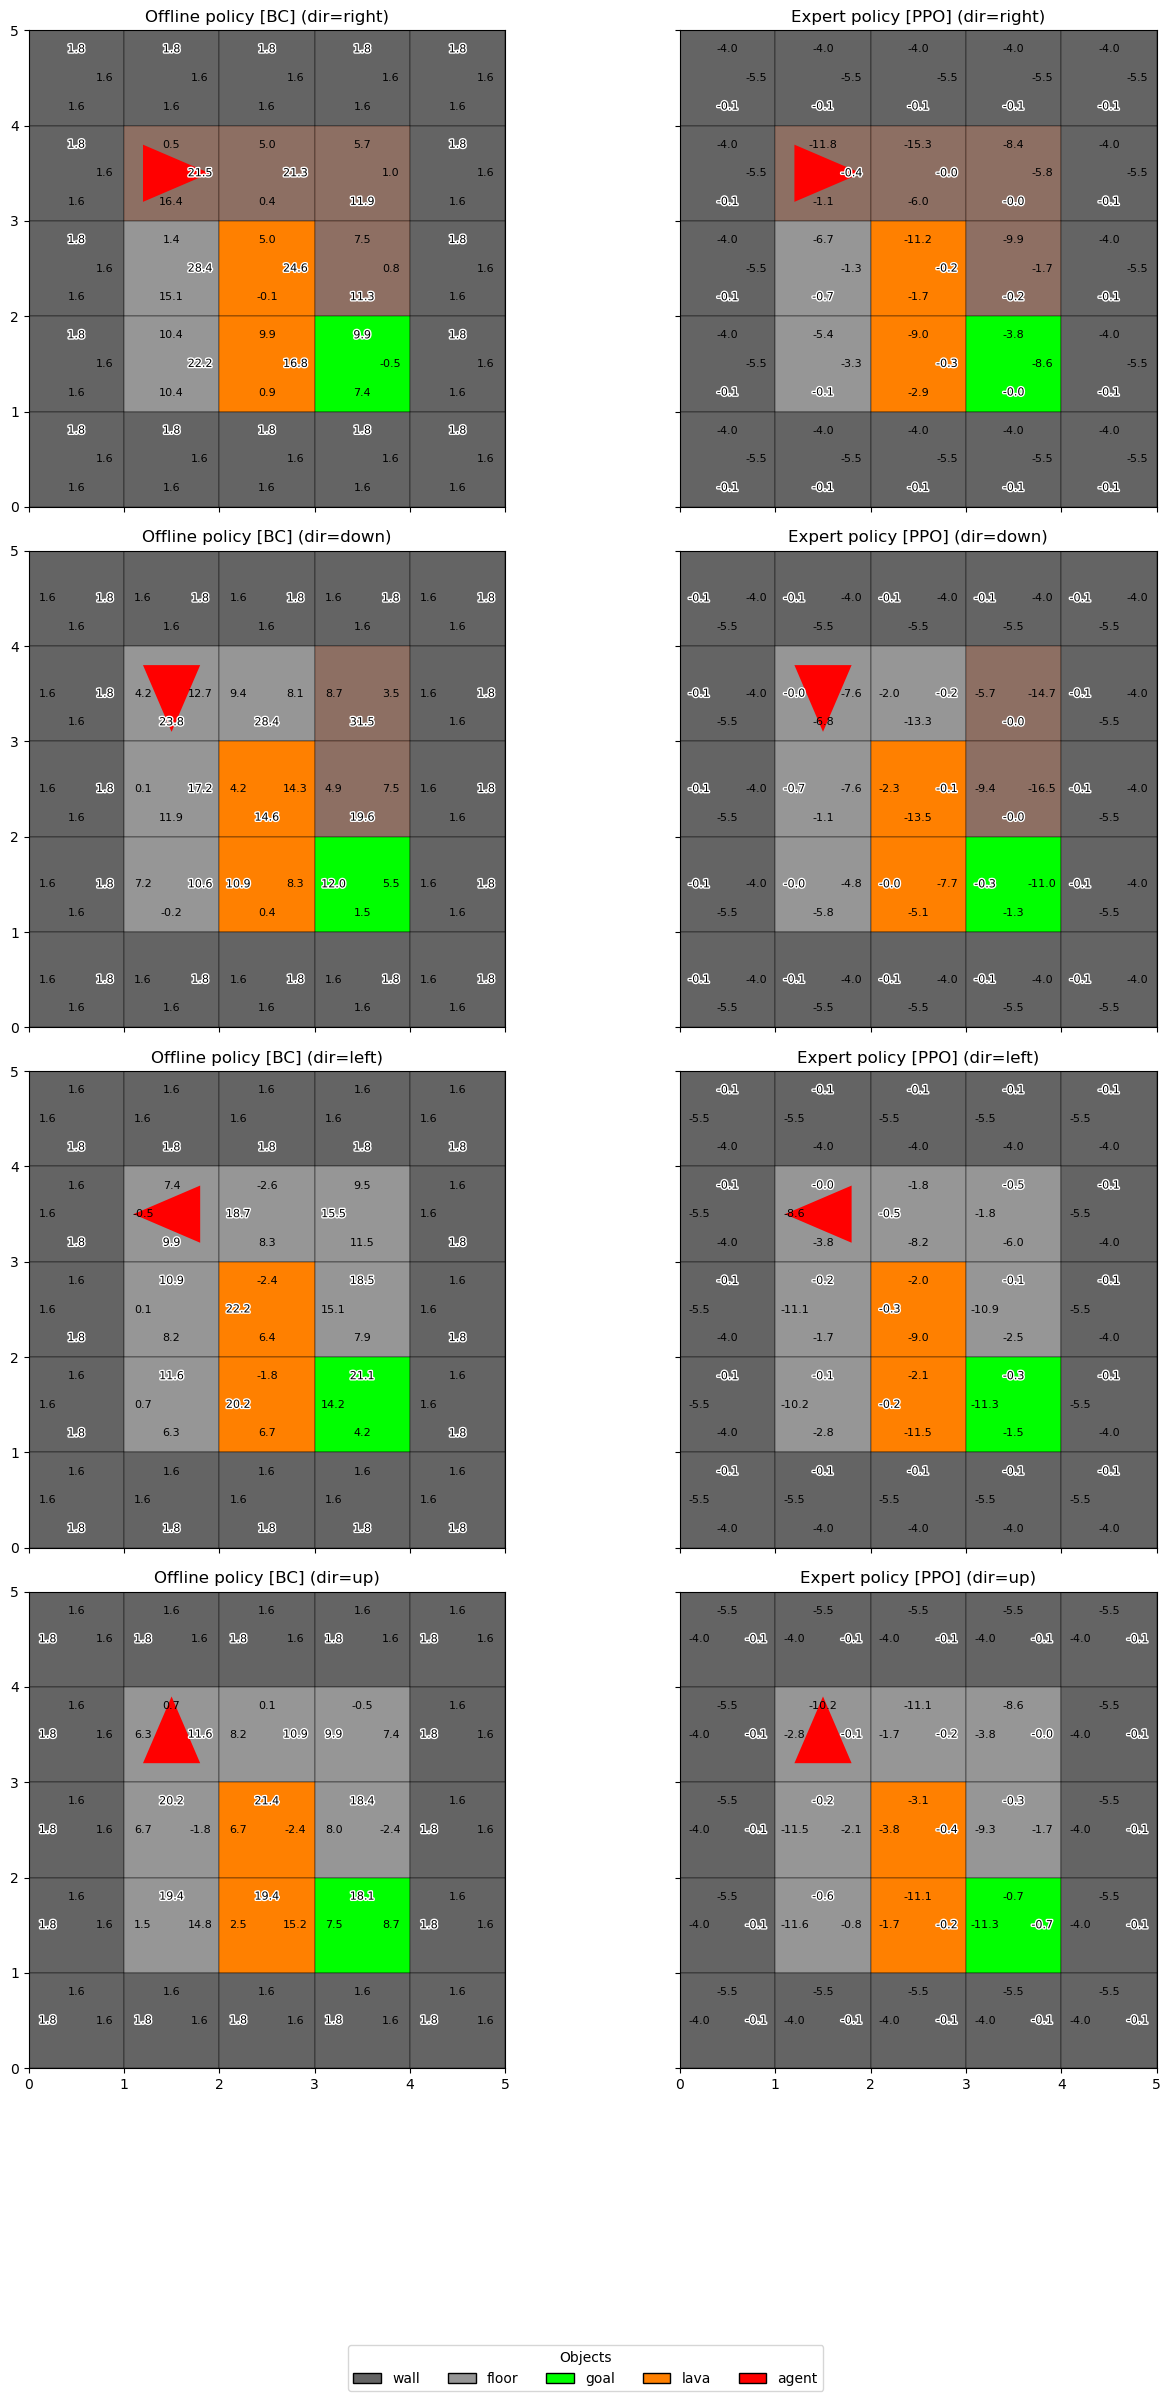

In [17]:
# VISUALIZE Q-VALUES and EXPERT STATE VISITATION for all states

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Patch
from matplotlib import patheffects as pe
import numpy as np
import re
import torch

from minigrid.core.constants import OBJECT_TO_IDX

IDX_TO_OBJECT = {v: k for k, v in OBJECT_TO_IDX.items()}

OBJECT_TO_COLOR = {
    "unseen": np.array([0, 0, 0]) / 255.0,
    "empty":  np.array([40, 40, 40]) / 255.0,
    "wall":   np.array([100, 100, 100]) / 255.0,
    "floor":  np.array([150, 150, 150]) / 255.0,
    "door":   np.array([180, 130, 80]) / 255.0,
    "key":    np.array([0, 170, 255]) / 255.0,
    "ball":   np.array([255, 170, 0]) / 255.0,
    "box":    np.array([150, 90, 40]) / 255.0,
    "goal":   np.array([0, 255, 0]) / 255.0,
    "lava":   np.array([255, 128, 0]) / 255.0,
    "agent":  np.array([255, 0, 0]) / 255.0,
}

# index mapping into the logits to get [left, forward, right]
OFFLINE_ACTIONS_TO_VIS = [0, 2, 1]  # env/BC: [left, right, forward] -> [left, forward, right]
EXPERT_ACTIONS_TO_VIS  = [0, 2, 1]  # PPO expert: same ordering

path = os.path.abspath("") + f"/logs/ppo/{ENV_NAME}/best_model"
agent = PPO.load(path)

# separate alphas
OVERLAY_ALPHA_QVALUES = 0.0
OVERLAY_ALPHA_STATE_FREQ = 0.35

STATE_FREQ_CMAP = plt.cm.Oranges

# eval env with fixed seed
model_dir = f"checkpoints/offline/bc/{DATASET_NAME}"
model_path = os.path.join(model_dir, "policy_latest.pt")

env = minari_dataset.recover_environment(render_mode=None)
observation_space = env.observation_space
action_space = env.action_space

policy_net = PolicyNetwork(observation_space, action_space.n)
policy_net.load_state_dict(torch.load(model_path, map_location="cpu"))
policy_net.eval()

obs, _ = env.reset(seed=ENV_SEED)

# unwrap to base MiniGrid env
wrappers = []
cur = env
while hasattr(cur, "env"):
    wrappers.append(cur)
    cur = cur.env
base_env = cur
wrappers_from_base = wrappers[::-1]

orig_pos = np.array(base_env.agent_pos)
orig_dir = int(base_env.agent_dir)
gap_x, gap_y = map(int, base_env.gap_pos)
goal_x, goal_y = map(int, base_env.goal_pos)
agent_x, agent_y = map(int, base_env.agent_pos)

grid_w = base_env.grid.width
grid_h = base_env.grid.height

m = re.search(r"S(\d+)", ENV_NAME)
if m:
    grid_size = int(m.group(1))
else:
    grid_size = grid_w

def wrapped_obs_at(x, y, agent_dir):
    base_env.agent_pos = np.array((x, y))
    base_env.agent_dir = agent_dir
    base_obs = base_env.gen_obs()
    obs_wrapped = base_obs
    for w in wrappers_from_base:
        if hasattr(w, "observation"):
            obs_wrapped = w.observation(obs_wrapped)
    return obs_wrapped

def obs_image(obs_wrapped):
    if isinstance(obs_wrapped, dict):
        return np.asarray(obs_wrapped["image"])
    return np.asarray(obs_wrapped)

def score_grid_from_policy(score_fn, n_actions, agent_dir):
    grid = np.zeros((grid_h, grid_w, n_actions), dtype=np.float32)
    for y in range(grid_h):
        for x in range(grid_w):
            obs_wrapped = wrapped_obs_at(x, y, agent_dir)
            grid[y, x, :] = score_fn(obs_wrapped)
    return grid

def bc_scores(obs_wrapped):
    obs_tensor = torch.as_tensor(obs_wrapped, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        q = policy_net(obs_tensor)
    return q.cpu().numpy().squeeze()

def expert_scores(obs_wrapped):
    img = obs_image(obs_wrapped)
    if img.ndim == 3:
        img = np.transpose(img, (2, 0, 1))
    elif img.ndim == 2:
        img = img[None, ...]
    obs_tensor = torch.as_tensor(img, dtype=torch.float32).unsqueeze(0).to(agent.device)
    with torch.no_grad():
        dist = agent.policy.get_distribution(obs_tensor)
        logits = dist.distribution.logits
    return logits.detach().cpu().numpy().squeeze()

# number of actions from offline policy
example_q = bc_scores(obs)
n_actions = example_q.shape[-1]

dirs = [0, 1, 2, 3]  # right, down, left, up
dir_names = {0: "right", 1: "down", 2: "left", 3: "up"}

offline_grids = {}
expert_grids = {}
for d in dirs:
    offline_grids[d] = score_grid_from_policy(bc_scores, n_actions, d)
    expert_grids[d] = score_grid_from_policy(expert_scores, n_actions, d)

# restore env state
base_env.agent_pos = orig_pos
base_env.agent_dir = orig_dir

def cell_object_name(x, y):
    if x == 0 or x == grid_w - 1 or y == 0 or y == grid_h - 1:
        return "wall"
    if (x, y) == (goal_x, goal_y):
        return "goal"
    if x == gap_x and 1 <= y <= grid_h - 2 and (x, y) != (gap_x, gap_y):
        return "lava"
    return "floor"

def draw_agent_triangle(ax, ax_cx, ax_cy, agent_dir):
    if agent_dir == 0:  # right
        tri = [(ax_cx + 0.2, ax_cy + 0.2),
               (ax_cx + 0.2, ax_cy + 0.8),
               (ax_cx + 0.9, ax_cy + 0.5)]
    elif agent_dir == 1:  # down
        tri = [(ax_cx + 0.2, ax_cy + 0.8),
               (ax_cx + 0.8, ax_cy + 0.8),
               (ax_cx + 0.5, ax_cy + 0.1)]
    elif agent_dir == 2:  # left
        tri = [(ax_cx + 0.8, ax_cy + 0.2),
               (ax_cx + 0.8, ax_cy + 0.8),
               (ax_cx + 0.1, ax_cy + 0.5)]
    else:  # up
        tri = [(ax_cx + 0.2, ax_cy + 0.2),
               (ax_cx + 0.8, ax_cy + 0.2),
               (ax_cx + 0.5, ax_cy + 0.9)]
    ax.add_patch(Polygon(tri, facecolor=OBJECT_TO_COLOR["agent"], edgecolor="none"))

def draw_single(ax, score_grid, agent_dir, title, cmap, norm, action_indices, state_freq_grid):
    for y in range(grid_h):
        for x in range(grid_w):
            obj_name = cell_object_name(x, y)
            bg = OBJECT_TO_COLOR[obj_name]
            cx, cy = x, grid_h - y - 1
            ax.add_patch(
                Rectangle((cx, cy), 1, 1, facecolor=bg, edgecolor="k", linewidth=0.3)
            )
            if state_freq_grid is not None and OVERLAY_ALPHA_STATE_FREQ > 0:
                freq = float(state_freq_grid[y, x])
                if freq > 0:
                    color = STATE_FREQ_CMAP(freq)
                    ax.add_patch(
                        Rectangle(
                            (cx, cy),
                            1,
                            1,
                            facecolor=color,
                            edgecolor="none",
                            alpha=OVERLAY_ALPHA_STATE_FREQ,
                        )
                    )

    ax_cx, ax_cy = agent_x, grid_h - agent_y - 1
    draw_agent_triangle(ax, ax_cx, ax_cy, agent_dir)

    mapping_by_dir = {
        0: {0: 1, 1: 2, 2: 3},  # dir=right: left->up, forward->right, right->down
        1: {0: 2, 1: 3, 2: 0},  # dir=down:  left->right, forward->down, right->left
        2: {0: 3, 1: 0, 2: 1},  # dir=left:  left->down, forward->left, right->up
        3: {0: 0, 1: 1, 2: 2},  # dir=up:    left->left, forward->up, right->right
    }

    for y in range(grid_h):
        for x in range(grid_w):
            cx, cy = x, grid_h - y - 1
            corners = [
                (cx, cy),
                (cx + 1, cy),
                (cx + 1, cy + 1),
                (cx, cy + 1),
            ]
            center = (cx + 0.5, cy + 0.5)

            triangles_abs = [
                [corners[0], corners[3], center],  # 0: left
                [corners[3], corners[2], center],  # 1: up
                [corners[2], corners[1], center],  # 2: right
                [corners[1], corners[0], center],  # 3: down
            ]
            text_pos_abs = [
                (cx + 0.2, cy + 0.5),
                (cx + 0.5, cy + 0.8),
                (cx + 0.8, cy + 0.5),
                (cx + 0.5, cy + 0.2),
            ]

            q_cell = score_grid[y, x]
            vals = [float(q_cell[a]) for a in action_indices]  # [left, forward, right]
            best_i = int(np.argmax(vals))
            dir_map = mapping_by_dir[agent_dir]

            for i, val in enumerate(vals):
                abs_idx = dir_map[i]
                tri = triangles_abs[abs_idx]
                tx, ty = text_pos_abs[abs_idx]

                if OVERLAY_ALPHA_QVALUES > 0:
                    color = cmap(norm(val))
                    ax.add_patch(Polygon(tri, color=color, alpha=OVERLAY_ALPHA_QVALUES))

                txt = ax.text(
                    tx,
                    ty,
                    f"{val:.1f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black",
                )
                if i == best_i:
                    txt.set_path_effects(
                        [pe.withStroke(linewidth=2, foreground="white")]
                    )

    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_xticks(np.arange(grid_size + 1))
    ax.set_yticks(np.arange(grid_size + 1))
    ax.set_aspect("equal")
    ax.set_title(title)

# ----------------------------------------------------------------------
# Expert state visitation counts from offline dataset (approximate match
# via observation images)
# ----------------------------------------------------------------------

# map obs image -> (x, y, dir)
obs_to_state = {}
for d in dirs:
    for y in range(grid_h):
        for x in range(grid_w):
            ow = wrapped_obs_at(x, y, d)
            img = obs_image(ow)
            key = img.tobytes()
            if key not in obs_to_state:
                obs_to_state[key] = (x, y, d)

state_visit_counts = np.zeros((len(dirs), grid_h, grid_w), dtype=np.int32)

for ep in minari_dataset:
    frames = np.asarray(ep.observations, dtype=np.uint8)
    if frames.ndim == 3:
        frames = frames[None, ...]
    T = len(ep.actions)
    for t in range(T):
        img = frames[t]
        key = img.tobytes()
        s = obs_to_state.get(key)
        if s is None:
            continue
        x, y, d = s
        state_visit_counts[d, y, x] += 1

if state_visit_counts.max() > 0:
    state_visit_freq = state_visit_counts.astype(np.float32) / state_visit_counts.max()
else:
    state_visit_freq = np.zeros_like(state_visit_counts, dtype=np.float32)

# ----------------------------------------------------------------------
# Shared color scale across all directions and both policies (Q-values)
# ----------------------------------------------------------------------
all_vals = np.concatenate(
    [
        offline_grids[d][:, :, OFFLINE_ACTIONS_TO_VIS].ravel()
        for d in dirs
    ]
    + [
        expert_grids[d][:, :, EXPERT_ACTIONS_TO_VIS].ravel()
        for d in dirs
    ]
)
vmin = float(all_vals.min())
vmax = float(all_vals.max())
cmap = plt.cm.viridis
norm = plt.Normalize(vmin, vmax)

fig, axes = plt.subplots(
    len(dirs), 2,
    figsize=(2 * grid_size + 4, len(dirs) * (grid_size + 1)),
    sharex=True,
    sharey=True,
)

for row, d in enumerate(dirs):
    ax_off = axes[row, 0]
    ax_exp = axes[row, 1]
    freq_grid = state_visit_freq[d]

    draw_single(
        ax_off,
        offline_grids[d],
        d,
        f"Offline policy [BC] (dir={dir_names[d]})",
        cmap,
        norm,
        OFFLINE_ACTIONS_TO_VIS,
        freq_grid,
    )
    draw_single(
        ax_exp,
        expert_grids[d],
        d,
        f"Expert policy [PPO] (dir={dir_names[d]})",
        cmap,
        norm,
        EXPERT_ACTIONS_TO_VIS,
        freq_grid,
    )

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

if OVERLAY_ALPHA_QVALUES > 0:
    plt.tight_layout(rect=[0, 0.12, 0.9, 1])
    cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(sm, cax=cax, label="score")
else:
    plt.tight_layout(rect=[0, 0.12, 1, 1])

legend_handles = [
    Patch(facecolor=OBJECT_TO_COLOR["wall"],  edgecolor="k", label="wall"),
    Patch(facecolor=OBJECT_TO_COLOR["floor"], edgecolor="k", label="floor"),
    Patch(facecolor=OBJECT_TO_COLOR["goal"],  edgecolor="k", label="goal"),
    Patch(facecolor=OBJECT_TO_COLOR["lava"],  edgecolor="k", label="lava"),
    Patch(facecolor=OBJECT_TO_COLOR["agent"], edgecolor="k", label="agent"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    title="Objects",
)

plt.show()